In [2]:
%load_ext autoreload
%autoreload 2

import data_analysis as da

In [18]:
import numpy as np
print(np.linspace(0.31, 0.39, 17))

[0.31  0.315 0.32  0.325 0.33  0.335 0.34  0.345 0.35  0.355 0.36  0.365
 0.37  0.375 0.38  0.385 0.39 ]


Importing L=16: cpp/csv/tmi/rppuc/tmi_rppuc_n_16_real_20000_0.3_0.39_res_19.csv
Importing L=20: cpp/csv/tmi/rppuc/tmi_rppuc_n_20_real_2500_0.31_0.37_res_13_corrected.csv
Importing L=24: cpp/csv/tmi/rppuc/tmi_rppuc_n_24_real_1000_0.31_0.36_res_6.csv
p-grid alignment: matched, 6 points
p_c = 0.31 ± nan
nu  = 3.1845752 ± nan
zeta = 0 fixed
collapse quality S = 3.8311779
The collapse is marginal; corrections to scaling may be relevant.


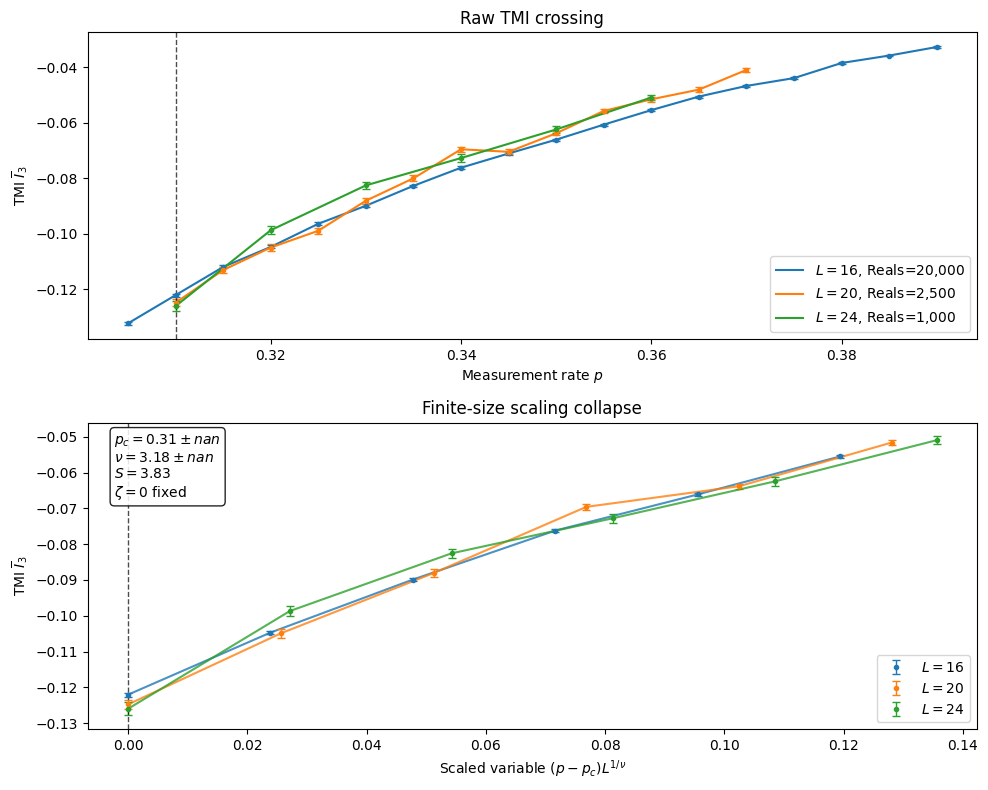

In [6]:
tmi = da.tmi_collapse(
    files=[
        "cpp/csv/tmi/rppuc/tmi_rppuc_n_16_real_20000_0.3_0.39_res_19.csv",
        "cpp/csv/tmi/rppuc/tmi_rppuc_n_20_real_2500_0.31_0.37_res_13_corrected.csv",
        "cpp/csv/tmi/rppuc/tmi_rppuc_n_24_real_1000_0.31_0.36_res_6.csv"
    ],
    sizes=[16, 20, 24],
    realizations=[20_000, 2500, 1000],
    p_range=(0.30, 0.4),
    pc0=0.33,
    nu0=2.0,
    fit_zeta=False,
)

In [48]:
import numpy as np
print(np.linspace(0.31, 0.37, 13))

[0.31  0.315 0.32  0.325 0.33  0.335 0.34  0.345 0.35  0.355 0.36  0.365
 0.37 ]


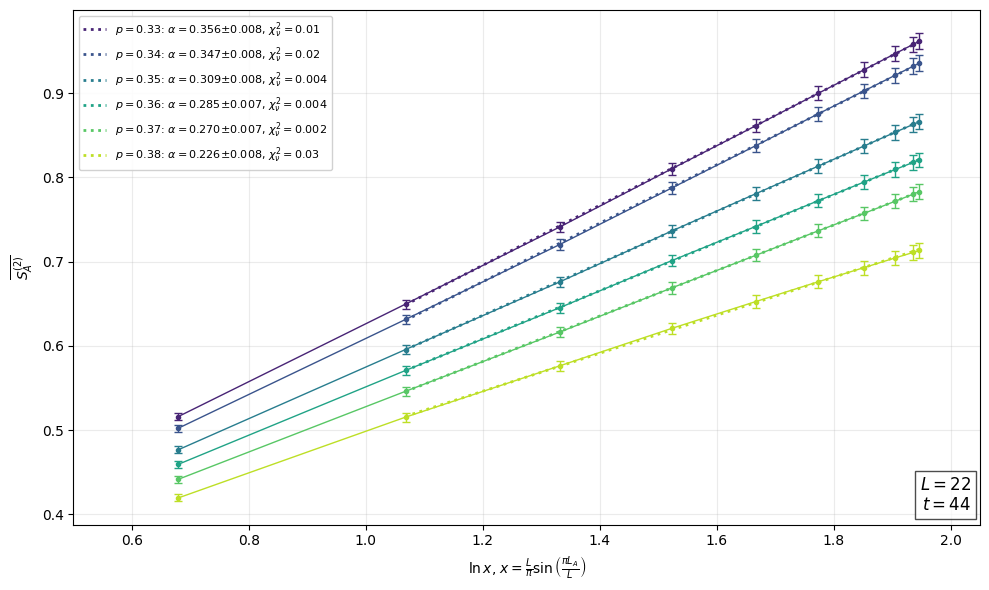

In [2]:
entropy_files = [
    f"cpp/csv/entropy/entropy_n22_p{p}_circ2_real1000.csv"
    for p in ["0.33", "0.34", "0.35", "0.36", "0.37", "0.38"]
]

entropy = da.entropy(
    entropy_files,
    fit_above_p=0.30,
    exclude_first=1,
    uncertainty="S2_stderr",
)

/home/communistcanada/mipt/.venv/lib/python3.10/site-packages/fssa/__init__.py:83: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


Importing L=12: cpp/csv/tmi/rppuc/tmi_rppuc_n_12_real_10000_0.3_0.39_res_19.csv
Importing L=16: cpp/csv/tmi/rppuc/tmi_rppuc_n_16_real_20000_0.3_0.36_res_13.csv
Importing L=20: cpp/csv/tmi/rppuc/tmi_rppuc_n_20_real_7500_0.31_0.39_res_5.csv
p-grid alignment: interpolated, 11 points
p_c = 0.355 ± 0.016
nu  = 2.9442552 ± 3
zeta = 0 fixed
collapse quality S = 17.589208
The collapse is very poor under the assumed scaling ansatz.


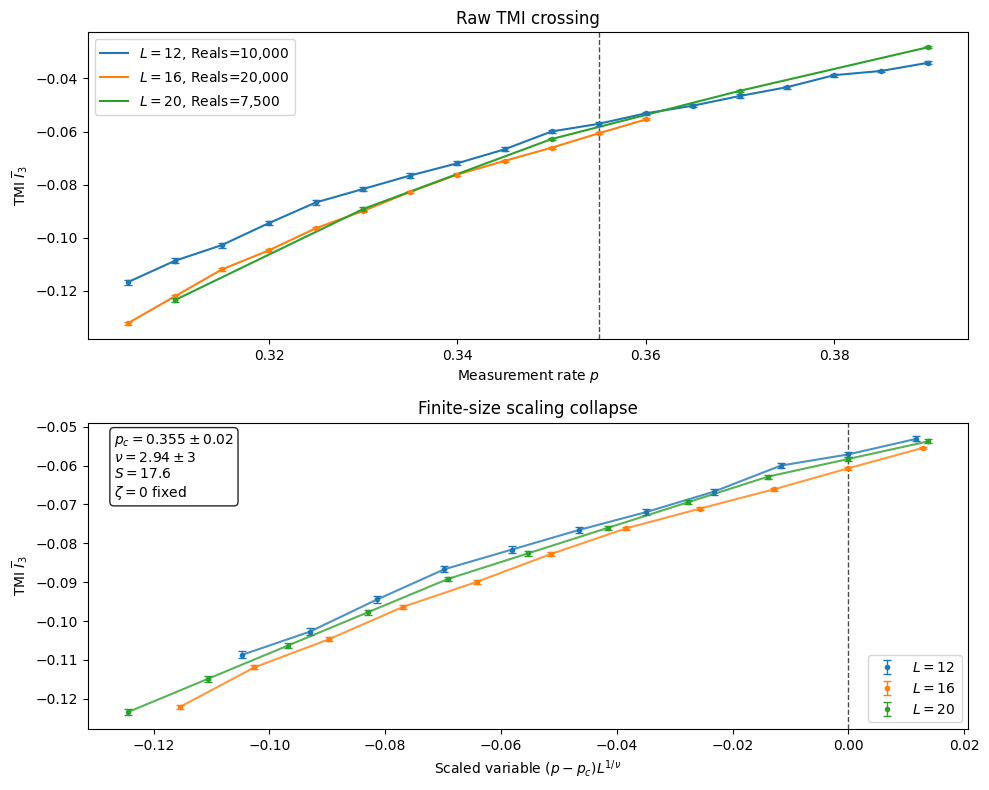

In [3]:
tmi = da.tmi_collapse(
    files=[
        "cpp/csv/tmi/rppuc/tmi_rppuc_n_12_real_10000_0.3_0.39_res_19.csv",
        "cpp/csv/tmi/rppuc/tmi_rppuc_n_16_real_20000_0.3_0.36_res_13.csv",
        "cpp/csv/tmi/rppuc/tmi_rppuc_n_20_real_7500_0.31_0.39_res_5.csv",
    ],
    sizes=[12, 16, 20],
    realizations=[10_000, 20_000, 7_500],
    p_range=(0.30, 0.39),
    pc0=0.33,
    nu0=2.0,
    fit_zeta=False,
)

Bootstrap fits: 25/200
Bootstrap fits: 50/200
Bootstrap fits: 75/200
Bootstrap fits: 100/200
Bootstrap fits: 125/200
Bootstrap fits: 150/200
Bootstrap fits: 175/200
Bootstrap fits: 200/200
z   = 1.046634 ± 0.008548
x_A = 0.226635 ± 0.006439
collapse score = 0.414211


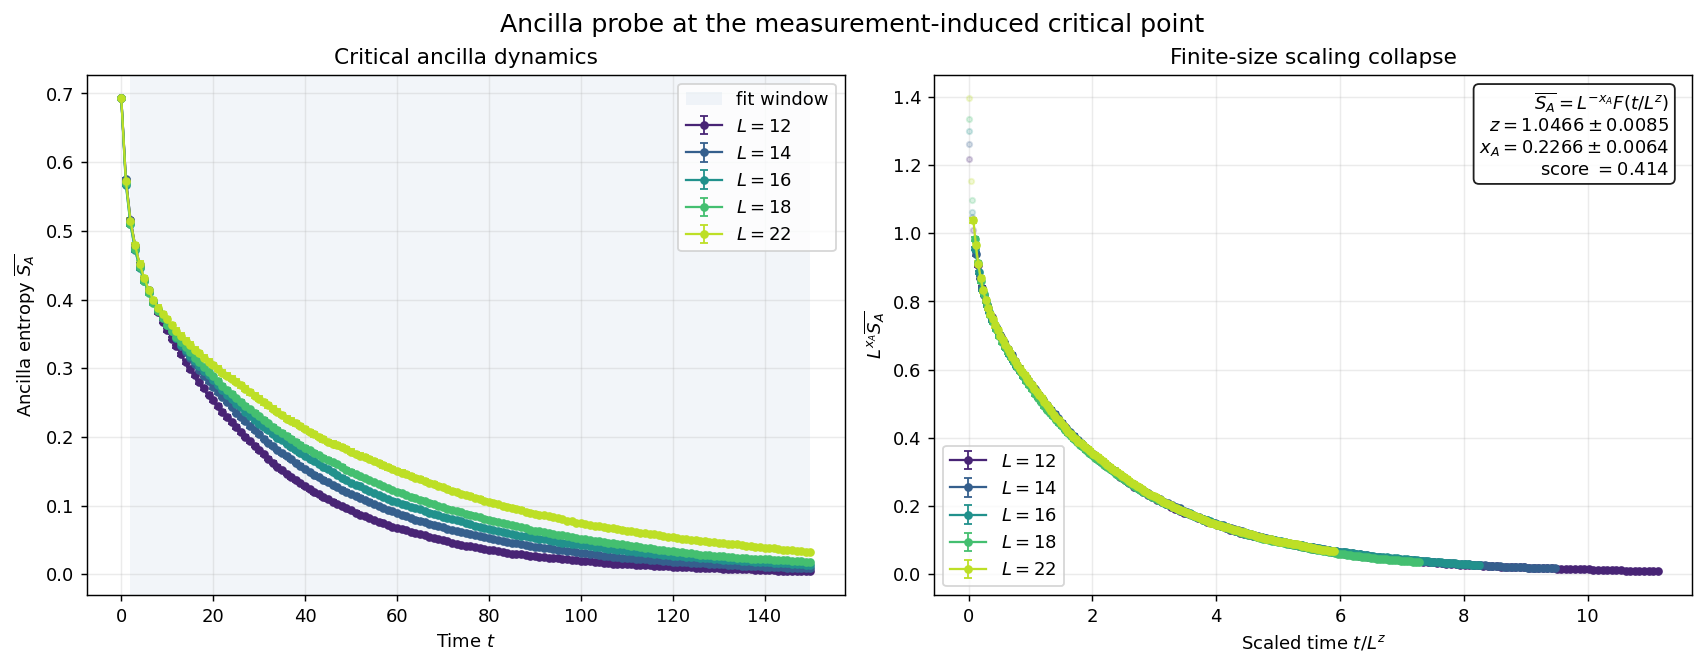

In [5]:
probe1 = da.probe1_collapse(
    file_glob="cpp/csv/probed/t_150/probed_rppu_n_*_p_0.333_d_1_*.csv",
    t_max=150,
    fit_t=(2, None),
    fixed_x_a=None,               # None fits both z and x_A
    z_bounds=(0.4, 2.5),
    bootstrap_samples=200,
    collapse_xscale="linear",
)

,L,metric,p_from_filename,points,x_min,x_max,negativity_max,x_at_negativity_max,file
0,8,negativity,0.333,65,0.0,8.0,0.242627,7.875,cpp/csv/2probed/reals_1000/2probed_rppu_n_8_p_...
1,12,negativity,0.333,97,0.0,8.0,0.235780,8.000,cpp/csv/2probed/reals_1000/2probed_rppu_n_12_p...
2,16,negativity,0.333,129,0.0,8.0,0.230895,7.750,cpp/csv/2probed/reals_1000/2probed_rppu_n_16_p...
3,20,negativity,0.333,161,0.0,8.0,0.212214,8.000,cpp/csv/2probed/reals_1000/2probed_rppu_n_20_p...


Bootstrap fits: 25/200
Bootstrap fits: 50/200
Bootstrap fits: 75/200
Bootstrap fits: 100/200
Bootstrap fits: 125/200
Bootstrap fits: 150/200
Bootstrap fits: 175/200
Bootstrap fits: 200/200
metric = negativity
eta = 0.125280 ± 0.003933
bootstrap 68% interval = [0.120935, 0.129055]
collapse score = 0.686821


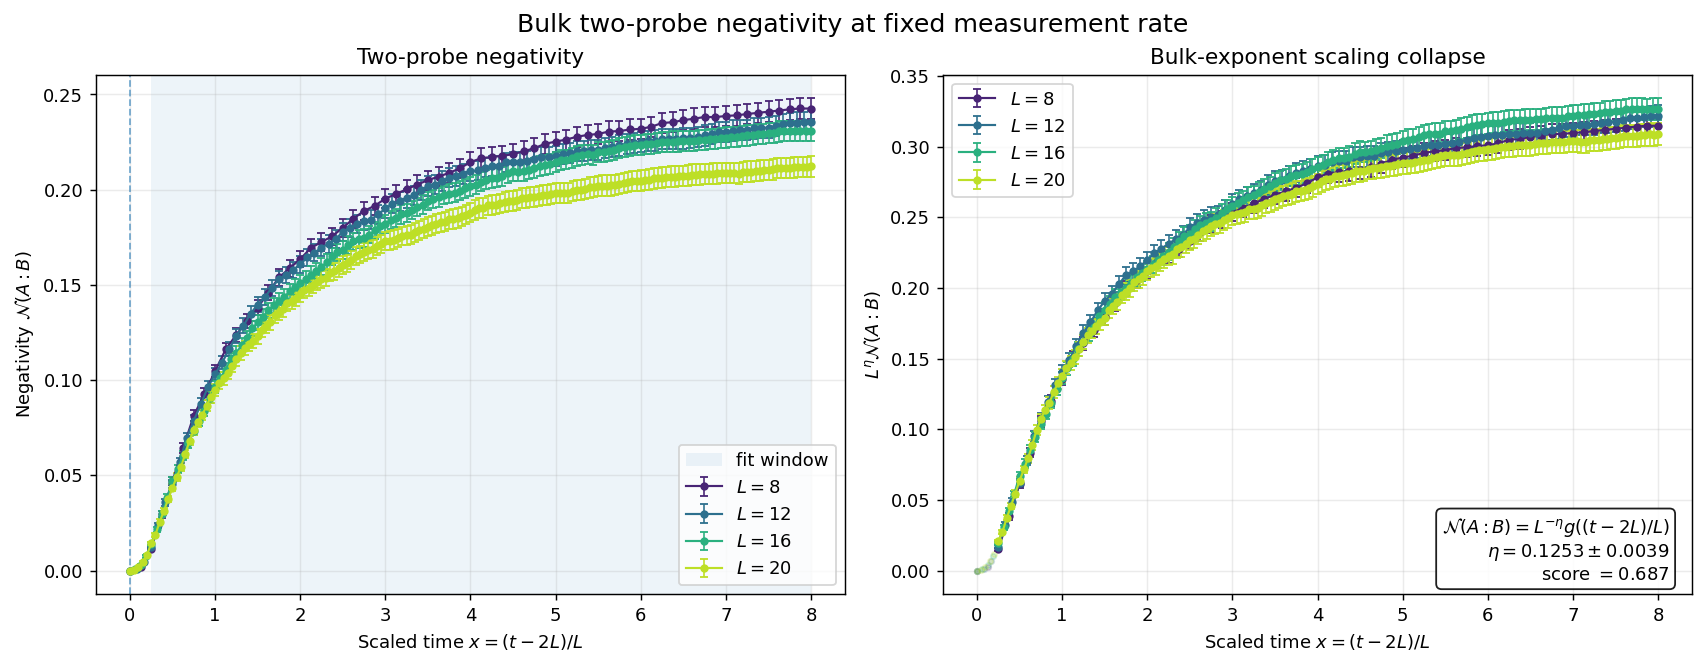

In [35]:
import importlib
import data_analysis

importlib.reload(data_analysis)

# Choose:
#   "mi"
#   "negativity"
#   "log_negativity"
METRIC = "negativity"

result = data_analysis.probe2_collapse(
    file_glob="cpp/csv/2probed/reals_1000/2probed_rppu_n_*_p_0.333_*.csv",
    metric=METRIC,
    x_load=(0.0, 8.0),
    fit_x=(0.25, 8.0),
    fit_i_min=1e-8,       # Applies to whichever metric is selected
    eta_bounds=(0.0, 2.0),
    bootstrap_samples=200,
    raw_yscale="linear",
    collapse_yscale="linear",
)

Importing L=16: cpp/csv/dist_scaling/rppu/dist_scaling_rppu_n_16_periods_32_p_0.333_real_10000.csv
Importing L=18: cpp/csv/dist_scaling/rppu/dist_scaling_rppu_n_18_periods_36_p_0.333_real_1000.csv
Importing L=20: cpp/csv/dist_scaling/rppu/dist_scaling_rppu_n_20_periods_40_p_0.333_real_1000.csv
Importing L=22: cpp/csv/dist_scaling/rppu/dist_scaling_rppu_n_22_periods_44_p_0.333_real_25000.csv


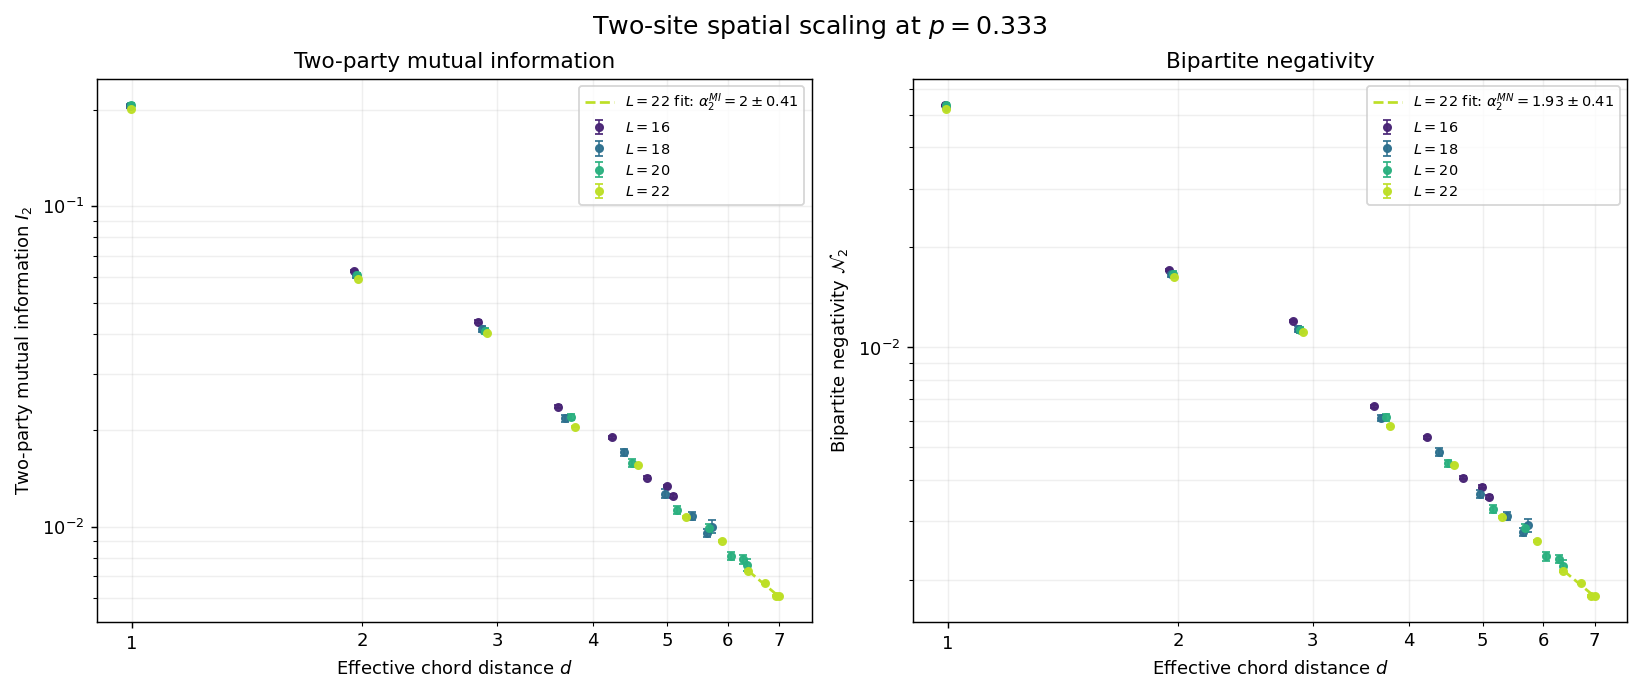

,L,file,distance_points_mi,distance_points_mn,rows_mi,rows_mn
0,16,cpp/csv/dist_scaling/rppu/dist_scaling_rppu_n_...,8,8,1200000,1200000
1,18,cpp/csv/dist_scaling/rppu/dist_scaling_rppu_n_...,9,9,153000,153000
2,20,cpp/csv/dist_scaling/rppu/dist_scaling_rppu_n_...,10,10,190000,190000
3,22,cpp/csv/dist_scaling/rppu/dist_scaling_rppu_n_...,11,11,5775000,5775000


,L,metric,alpha,alpha_stderr,prefactor,log_prefactor,log_prefactor_stderr,reduced_chi2,d_min,d_max,points
0,16,mi,2.204502,0.208686,0.451162,-0.795929,0.325286,1.530502,4.234640,5.092958,4
1,16,mn,2.147933,0.208686,0.117328,-2.142785,0.325286,1.339786,4.234640,5.092958,4
2,18,mi,1.983970,0.294584,0.304356,-1.189558,0.495265,0.922679,4.961960,5.729578,4
3,18,mn,1.825879,0.291887,0.067248,-2.699372,0.491031,1.019050,4.961960,5.729578,4
4,20,mi,2.216539,0.363810,0.456001,-0.785259,0.654800,1.192039,5.672324,6.366198,4
5,20,mn,2.154887,0.360517,0.118400,-2.133688,0.649153,1.297277,5.672324,6.366198,4
6,22,mi,2.003040,0.406938,0.298486,-1.209032,0.777290,0.262596,6.369987,7.002817,4
7,22,mn,1.929299,0.406938,0.075918,-2.578099,0.777290,0.236452,6.369987,7.002817,4


,L,metric,alpha,alpha_stderr,prefactor,log_prefactor,log_prefactor_stderr,reduced_chi2,d_min,d_max,points
0,16,mi,2.204502,0.208686,0.451162,-0.795929,0.325286,1.530502,4.234640,5.092958,4
1,16,mn,2.147933,0.208686,0.117328,-2.142785,0.325286,1.339786,4.234640,5.092958,4
2,18,mi,1.983970,0.294584,0.304356,-1.189558,0.495265,0.922679,4.961960,5.729578,4
3,18,mn,1.825879,0.291887,0.067248,-2.699372,0.491031,1.019050,4.961960,5.729578,4
4,20,mi,2.216539,0.363810,0.456001,-0.785259,0.654800,1.192039,5.672324,6.366198,4
5,20,mn,2.154887,0.360517,0.118400,-2.133688,0.649153,1.297277,5.672324,6.366198,4
6,22,mi,2.003040,0.406938,0.298486,-1.209032,0.777290,0.262596,6.369987,7.002817,4
7,22,mn,1.929299,0.406938,0.075918,-2.578099,0.777290,0.236452,6.369987,7.002817,4


In [44]:
import importlib
import data_analysis

# Reload after replacing data_analysis.py.
importlib.reload(data_analysis)

# ------------------------------------------------------------------
# Input files
# The sizes can also be inferred automatically from "_n_<N>_" in
# each filename. Supplying SIZES explicitly makes the setup clearer.
# ------------------------------------------------------------------
FILES = [
    "cpp/csv/dist_scaling/rppu/dist_scaling_rppu_n_16_periods_32_p_0.333_real_10000.csv",
    "cpp/csv/dist_scaling/rppu/dist_scaling_rppu_n_18_periods_36_p_0.333_real_1000.csv",
    "cpp/csv/dist_scaling/rppu/dist_scaling_rppu_n_20_periods_40_p_0.333_real_1000.csv",
    "cpp/csv/dist_scaling/rppu/dist_scaling_rppu_n_22_periods_44_p_0.333_real_25000.csv",
    # "cpp/csv/dist_scaling/rppu/dist_scaling_rppu_n_24_periods_48_p_0.333_real_1000.csv",
    # "cpp/csv/dist_scaling/rppu/dist_scaling_rppu_n_26_periods_52_p_0.333_real_100.csv"
    
]

SIZES = [16, 18, 20, 22]#, 24]#, 26]

# ------------------------------------------------------------------
# Fit controls
#
# None means: use the FIT_LAST_* largest positive-distance points.
#
# A common explicit distance window can instead be given as:
# FIT_RANGE_MI = (3.0, 6.0)
#
# Different windows for different sizes are also supported:
# FIT_RANGE_MI = {
#     12: (2.0, 3.8),
#     16: (3.0, 5.0),
#     20: (4.0, 6.4),
# }
# ------------------------------------------------------------------
FIT_RANGE_MI = None
FIT_RANGE_MN = None

FIT_LAST_MI = 4
FIT_LAST_MN = 4

# Dashed lines are plotted for these sizes.
# Fits for every size remain available in result["fits"].
FIT_SIZE_MI = max(SIZES)
FIT_SIZE_MN = max(SIZES)

result = data_analysis.dist_scaling(
    files=FILES,
    sizes=SIZES,

    fit_size_mi=FIT_SIZE_MI,
    fit_size_mn=FIT_SIZE_MN,

    fit_range_mi=FIT_RANGE_MI,
    fit_range_mn=FIT_RANGE_MN,
    fit_last_mi=FIT_LAST_MI,
    fit_last_mn=FIT_LAST_MN,

    min_relative_error=0.03,
    chunksize=1_000_000,

    title=r"Two-site spatial scaling at $p=0.333$",
)

# Numerical fit results:
result["fits"]

,L,metric,p_from_filename,points,x_min,x_max,value_min,value_max,abs_max,x_at_abs_max,file
0,8,i2,0.333,65,0.0,8.0,0.000000e+00,0.274085,0.274085,8.0,cpp/4probed_rppu_n_8_p_0.333_reals_1k_t_16_80.csv
1,12,i2,0.333,97,0.0,8.0,4.785061e-17,0.272243,0.272243,8.0,cpp/4probed_rppu_n_12_p_0.333_reals_1k_t_24_12...
2,16,i2,0.333,129,0.0,8.0,0.000000e+00,0.253953,0.253953,8.0,cpp/4probed_rppu_n_16_p_0.333_reals_1k_t_32_16...


Bootstrap fits: 25/200
Bootstrap fits: 50/200
Bootstrap fits: 75/200
Bootstrap fits: 100/200
Bootstrap fits: 125/200
Bootstrap fits: 150/200
Bootstrap fits: 175/200
Bootstrap fits: 200/200
metric = i2
eta = 0.088664 ± 0.002922
bootstrap 68% interval = [0.086014, 0.091432]
collapse score = 4.84262


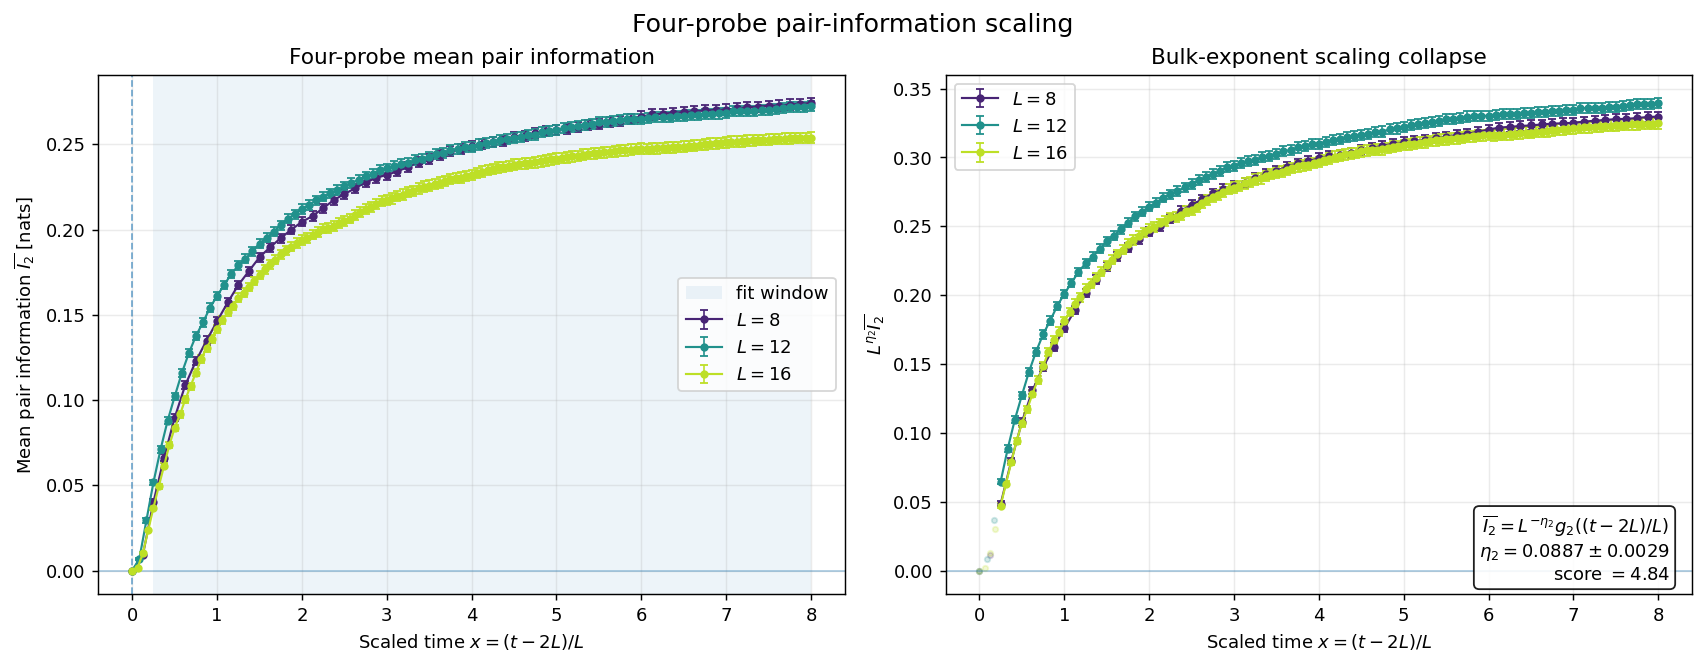

In [42]:
import importlib
import data_analysis

importlib.reload(data_analysis)

# Choose: "i2", "i3", or "i4"
METRIC = "i2"

files = [
    "cpp/4probed_rppu_n_8_p_0.333_reals_1k_t_16_80.csv",
    "cpp/4probed_rppu_n_12_p_0.333_reals_1k_t_24_120.csv",
    "cpp/4probed_rppu_n_16_p_0.333_reals_1k_t_32_160.csv"
]

result = data_analysis.probe4_collapse(
    files=files,
    metric=METRIC,
    x_load=(0.0, 8.0),
    fit_x=(0.25, 8.0),
    fit_abs_min=1e-8,
    eta_bounds=(0.0, 8.0),
    bootstrap_samples=200,
    raw_yscale="linear",
    collapse_yscale="linear",
)

sq: p_c=0.341404 ± 0.0292, nu=2.432 ± 1.91, x=0 ± 0, score=0.752461


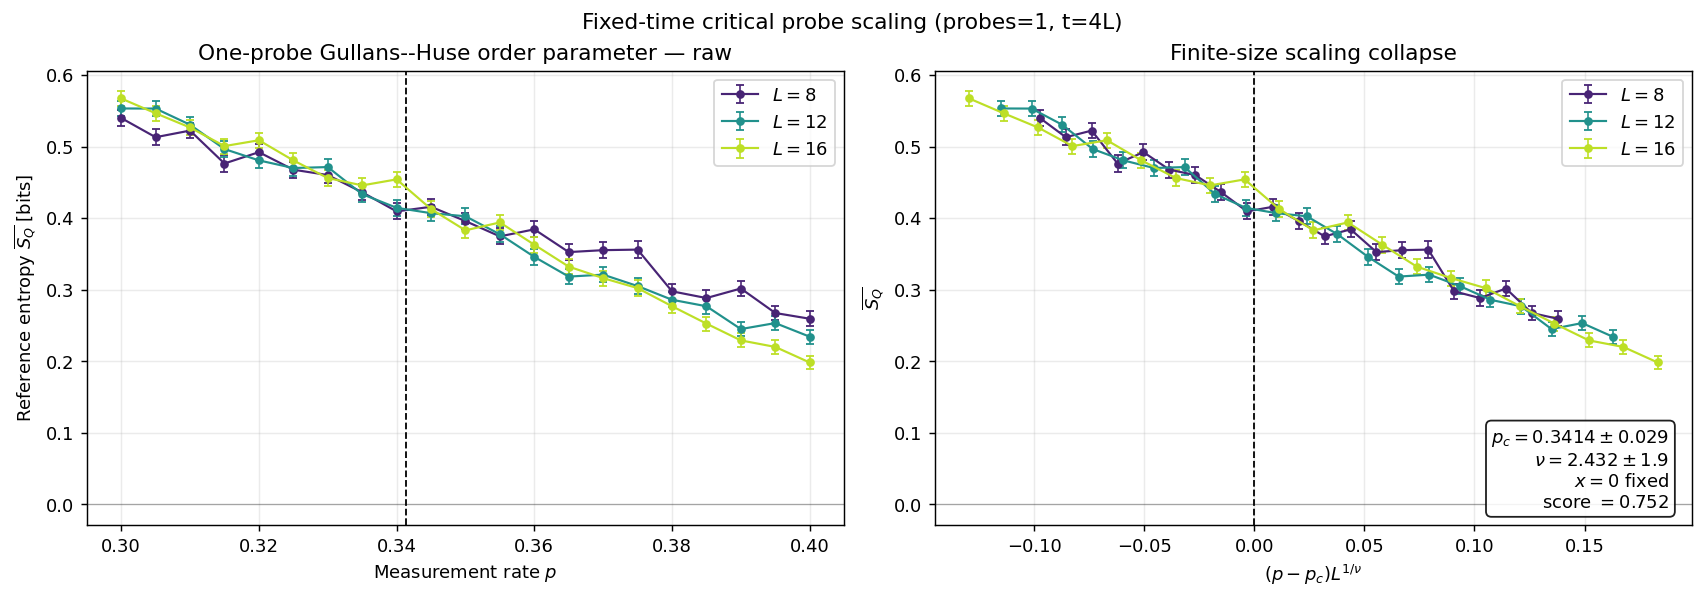

In [3]:
import data_analysis as da

# Automatically makes:
# probes=1: one raw/collapse pair
# probes=2: I2 raw/collapse pair
# probes=4: stacked I2, I3, I4 raw/collapse pairs
result = da.probe_pc_collapse(
    file_glob="cpp/probed_1_rppu_n_*_mode_1*.csv",
    pc_bounds=(0.28, 0.41),
)